In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
os.chdir("../data/")

In [5]:
pome_cpu = pd.read_csv("benchmark_results_pome.csv")
pome_cpu["Method"] = "POME(CPU)"
pome_gpu = pd.read_csv("benchmark_results_pome_GPU.csv")
pome_gpu["Method"] = "POME(GPU)"

pome_gpu["Peak Memory"] = pome_gpu["Peak VRAM"]/1000.0
pome_cpu["Peak Memory"] = pome_cpu["Peak Memory"]/1000.0

pome_gpu = pome_gpu.drop(columns=["Peak VRAM"])
all_df = pd.concat([pome_cpu, pome_gpu], ignore_index=True)
all_df

,Samples,Run,Runtime,Peak Memory,Method
0,2000,0,197.073877,3.987152,POME(CPU)
1,2000,1,196.033694,3.965895,POME(CPU)
2,2000,2,198.109735,3.988043,POME(CPU)
3,2000,3,203.337829,3.990105,POME(CPU)
4,2000,4,191.404065,3.986668,POME(CPU)
5,4000,0,368.789249,7.190719,POME(CPU)
6,4000,1,363.917028,7.186801,POME(CPU)
7,4000,2,376.047176,7.144828,POME(CPU)
8,4000,3,359.093037,7.125430,POME(CPU)
9,4000,4,366.097989,7.144836,POME(CPU)


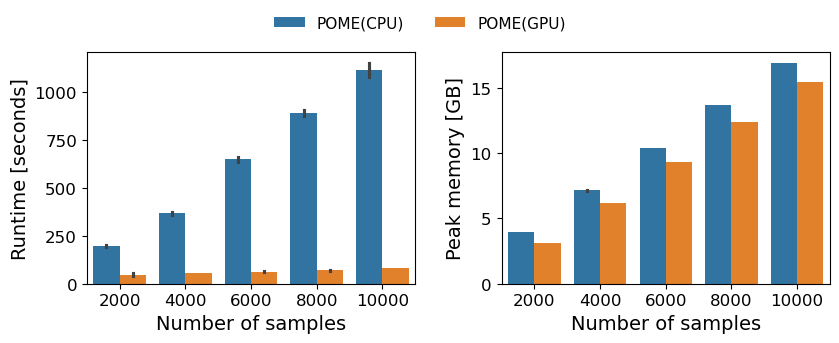

In [6]:
fig, axs = plt.subplot_mosaic([['A', 'B']])
fig.set_size_inches(8.5, 3.5)

label_fontsize = 16

sns.barplot(data=all_df, x="Samples", y="Runtime",
             hue="Method", ax=axs['A'],
             legend=False, errorbar="sd")
axs['A'].set_xlabel('Number of samples', fontsize=label_fontsize-2) 
axs['A'].set_ylabel('Runtime [seconds]', fontsize=label_fontsize-2) 
axs['A'].tick_params(axis='x', labelsize=label_fontsize-4) 
axs['A'].tick_params(axis='y', labelsize=label_fontsize-4)  

sns.barplot(data=all_df, x="Samples", y="Peak Memory",
             hue="Method", ax=axs["B"], errorbar="sd")
axs['B'].set_xlabel('Number of samples', fontsize=label_fontsize-2) 
axs['B'].set_ylabel('Peak memory [GB]', fontsize=label_fontsize-2) 
axs['B'].tick_params(axis='x', labelsize=label_fontsize-4) 
axs['B'].tick_params(axis='y', labelsize=label_fontsize-4) 


handles, labels = axs["B"].get_legend_handles_labels()
axs["B"].legend_.remove()

# Shared legend ABOVE plots
fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 0.99),
           ncol=len(labels),
           fontsize=label_fontsize-5,
           frameon=False)

fig.tight_layout(rect=[0, 0, 1, 0.9])  # leave top space
#fig.subplots_adjust(hspace=0.4, wspace=0.3)
#plt.show()
plt.savefig("resource_benchmark.pdf", format='pdf')